In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [2]:

# Problem Setup

states = 11
actions = 3
gamma = 0.95
theta = 1e-6

action_names = ["Hover","Descent","Boost"]


# Reward Matrix

R = np.array([
[-5,-7,-13],
[-5,-7,-13],
[-5,-7,-13],
[-5,-7,-13],
[20,18,12],
[20,18,12],
[20,18,12],
[-5,-7,-13],
[-5,-7,-13],
[-5,-7,-13],
[-500,-502,-508]
])

# Transition Matrix P[s,a,s']

P = np.zeros((states - 1,actions,states))

# Hover
for s in range(10):
    P[s,0,s] += 0.6
    P[s,0,min(s+1,10)] += 0.4

# Controlled Descent
for s in range(10):
    P[s,1,max(0,s-1)] += 0.48
    P[s,1,s] += 0.44
    P[s,1,min(s+1,10)] += 0.08

# Emergency Boost
for s in range(7):
    P[s,2,max(0, s-3)] = 1

# Emergency Boost
P[7,2,4] = 0.75
P[7,2,10] = 0.25

P[8,2,5] = 0.75
P[8,2,10] = 0.25

P[9,2,6] = 0.75
P[9,2,10] = 0.25

print("Transition Matrix P:")
print(P)



Transition Matrix P:
[[[0.6  0.4  0.   0.   0.   0.   0.   0.   0.   0.   0.  ]
  [0.92 0.08 0.   0.   0.   0.   0.   0.   0.   0.   0.  ]
  [1.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.  ]]

 [[0.   0.6  0.4  0.   0.   0.   0.   0.   0.   0.   0.  ]
  [0.48 0.44 0.08 0.   0.   0.   0.   0.   0.   0.   0.  ]
  [1.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.  ]]

 [[0.   0.   0.6  0.4  0.   0.   0.   0.   0.   0.   0.  ]
  [0.   0.48 0.44 0.08 0.   0.   0.   0.   0.   0.   0.  ]
  [1.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.  ]]

 [[0.   0.   0.   0.6  0.4  0.   0.   0.   0.   0.   0.  ]
  [0.   0.   0.48 0.44 0.08 0.   0.   0.   0.   0.   0.  ]
  [1.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.  ]]

 [[0.   0.   0.   0.   0.6  0.4  0.   0.   0.   0.   0.  ]
  [0.   0.   0.   0.48 0.44 0.08 0.   0.   0.   0.   0.  ]
  [0.   1.   0.   0.   0.   0.   0.   0.   0.   0.   0.  ]]

 [[0.   0.   0.   0.   0.   0.6  0.4  0.   0.   0.   0.  ]
  [0.   0.   0.   0.   0.

Optimal Value Function V*
State 0 : 206.33823316323884
State 1 : 246.64589781262413
State 2 : 292.25720254726184
State 3 : 343.8699947467903
State 4 : 375.9581543408006
State 5 : 372.7947559864612
State 6 : 362.2319804335923
State 7 : 326.6395367099363
State 8 : 262.1898446011558
State 9 : 140.09028537833944
State 10 : 0.0


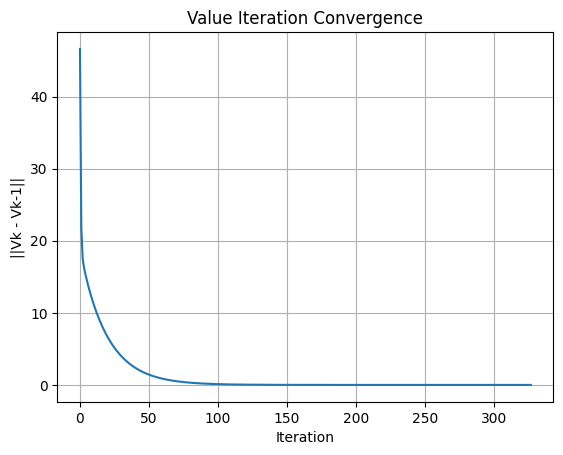

In [3]:
# VALUE ITERATION (Task B)

V = np.zeros(states)
deltas = []

while True:

    delta = 0
    V_new = np.copy(V)

    for s in range(states - 1):

        action_values = []

        for a in range(actions):

            val = 0
            for next_state in range(states):
                val += P[s,a,next_state]*(R[next_state,a] + gamma*V[next_state])

            action_values.append(val)

        V_new[s] = max(action_values)
        delta = max(delta, abs(V_new[s] - V[s]))

    V = V_new
    deltas.append(delta)

    if delta < theta:
        break

print("Optimal Value Function V*")
for s in range(states):
    print("State", s, ":", V[s])

# Convergence Plot
plt.figure()
plt.plot(deltas)
plt.xlabel("Iteration")
plt.ylabel("||Vk - Vk-1||")
plt.title("Value Iteration Convergence")
plt.grid(True)
plt.show()

Optimal Value Function V*
State 0 : 206.33823761557352
State 1 : 246.64590280843177
State 2 : 292.2572080648803
State 3 : 343.8700007654186
State 4 : 375.9581608404645
State 5 : 372.7947629479806
State 6 : 362.23198783043654
State 7 : 326.63954447418763
State 8 : 262.18985240798764
State 9 : 140.09029132918602
State 10 : 0.0

Action values Q
        Hover     Descent       Boost
0  206.338239  192.084708  183.021326
1  246.645904  212.399772  183.021326
2  292.257209  253.768165  183.021326
3  343.870002  300.579767  183.021326
4  375.958162  348.287634  221.313608
5  370.141170  372.794763  264.644348
6  340.595260  362.231988  313.676501
7  280.816684  326.639545  149.870190
8  197.682527  262.189853  147.616269
9 -123.148534  131.516314  140.090291

Optimal Policy (π*)
State 0 -> Hover
State 1 -> Hover
State 2 -> Hover
State 3 -> Hover
State 4 -> Hover
State 5 -> Descent
State 6 -> Descent
State 7 -> Descent
State 8 -> Descent
State 9 -> Boost


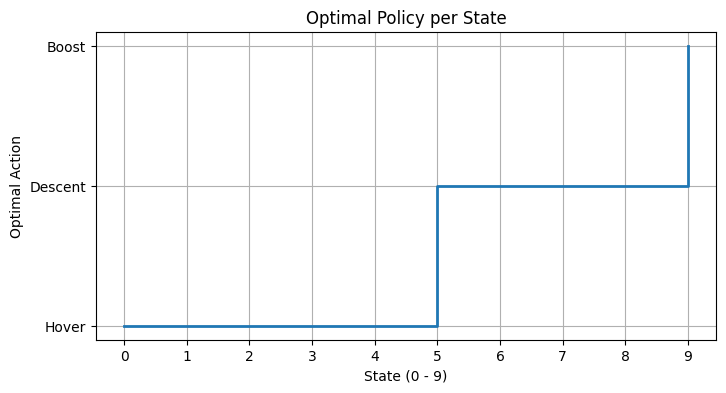

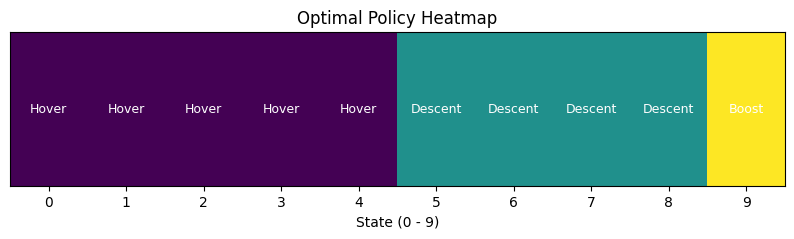

In [4]:

# POLICY ITERATION (Task C)

policy = np.full((states - 1, actions), 1/3)
V = np.zeros(states)

stable = False
Q = np.zeros((states - 1, actions))

while not stable:

    # Policy Evaluation
    while True:

        delta = 0

        for s in range(states - 1):
            v = 0
            for a in range(actions):
                for next_state in range(states):
                    v += policy[s, a] * P[s, a, next_state] * (R[next_state, a] + gamma * V[next_state])

            delta = max(delta, abs(v - V[s]))
            V[s] = v

        if delta < theta:
            break

    # Policy Improvement
    stable = True

    for s in range(states - 1):

        old_policy = policy[s].copy()

        for a in range(actions):

            val = 0
            for next_state in range(states):
                val += P[s,a,next_state]*(R[next_state,a] + gamma*V[next_state]) 
            Q[s, a] = val

        best_action = np.argmax(Q[s])
        policy[s] = np.zeros(actions)  # Reset to zero
        policy[s, best_action] = 1.0   # Set greedy action to 1
        
        if not np.array_equal(old_policy, policy[s]):
            stable = False

optimal_actions = np.argmax(policy, axis=1)

print("Optimal Value Function V*")
for s in range(states):
    print("State", s, ":", V[s])

print("\nAction values Q")

df_q = pd.DataFrame(Q, columns=action_names, index=range(states - 1))
print(df_q)

print("\nOptimal Policy (π*)")

for s in range(states - 1):
    print("State", s, "->", action_names[optimal_actions[s]])


# POLICY STEP GRAPH

plt.figure(figsize=(8,4))
plt.step(range(states - 1), optimal_actions, where='post', linewidth=2)

plt.xticks(range(states - 1))
plt.yticks([0,1,2], action_names)

plt.xlabel("State (0 - 9)")
plt.ylabel("Optimal Action")

plt.title("Optimal Policy per State")

plt.grid(True)

plt.show()

# POLICY HEATMAP

plt.figure(figsize=(10,2))
plt.imshow([optimal_actions], cmap="viridis", aspect="auto")

plt.yticks([])
plt.xticks(range(states - 1))

for i in range(states - 1):
    plt.text(i,0,action_names[optimal_actions[i]],
             ha="center",va="center",
             color="white",fontsize=9)

plt.xlabel("State (0 - 9)")
plt.title("Optimal Policy Heatmap")

plt.show()